# Store Sales Time Series Forecasting

## 1. Project Overview

**Goal:** Forecast store sales for Corporación Favorita — a large Ecuadorian grocery retailer.

**Why this is interesting:**
- Real competition data from Kaggle
- Multiple external factors: oil prices, holidays, store types
- Ecuador is an oil-dependent economy — oil prices directly affect consumer spending

**Dataset files:**
- `train.csv` — historical sales by store and product family
- `test.csv` — dates to forecast
- `stores.csv` — store metadata (city, type, cluster)
- `oil.csv` — daily oil prices
- `holidays_events.csv` — holidays and events in Ecuador
- `transactions.csv` — daily transaction counts per store

**Target variable:** `sales` — units of a product family sold at a store on a given date

## 2. Loading Data & imports

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
train = pd.read_csv("../data/train.csv")
stores = pd.read_csv("../data/stores.csv")
oil = pd.read_csv("../data/oil.csv")
holidays = pd.read_csv("../data/holidays_events.csv")

In [36]:
train

,id,date,store_nbr,family,sales,onpromotion,day_of_week
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,1
1,1,2013-01-01,1,BABY CARE,0.000,0,1
2,2,2013-01-01,1,BEAUTY,0.000,0,1
3,3,2013-01-01,1,BEVERAGES,0.000,0,1
4,4,2013-01-01,1,BOOKS,0.000,0,1
...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,1
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,1
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,1


In [10]:
train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           3000888 non-null  int64  
 1   date         3000888 non-null  str    
 2   store_nbr    3000888 non-null  int64  
 3   family       3000888 non-null  str    
 4   sales        3000888 non-null  float64
 5   onpromotion  3000888 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [7]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [13]:
train['date'] = pd.to_datetime(train['date'])

In [14]:
train['date'].dtype

dtype('<M8[us]')

In [15]:
daily_sales = train.groupby('date').agg(
    total_sales=('sales', 'sum')
)

<Axes: xlabel='date'>

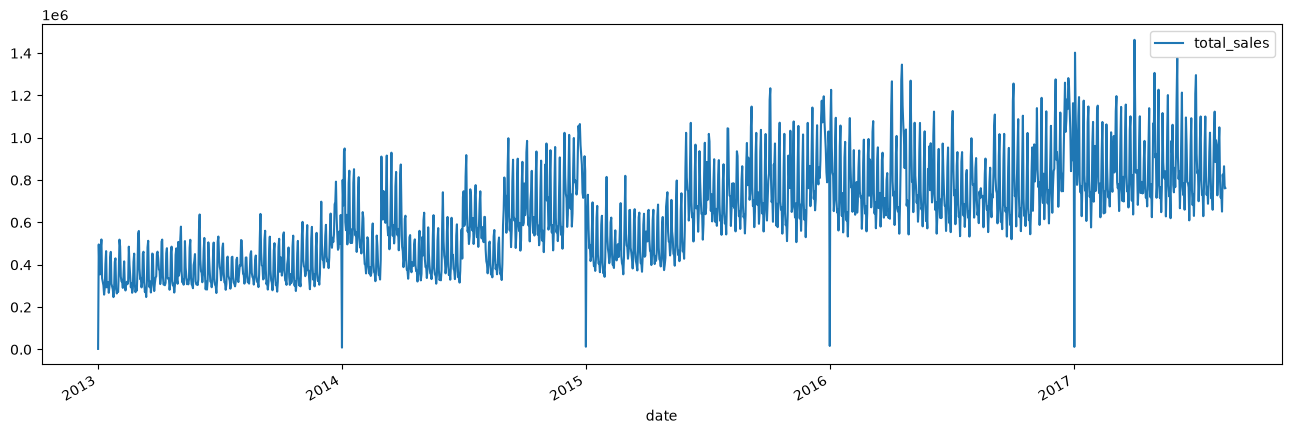

In [24]:
daily_sales.plot(figsize=(16, 5))

In [25]:
train['day_of_week'] = train['date'].dt.dayofweek

In [26]:
week_sales = train.groupby('day_of_week').agg(
    total_sales_wek=('sales', 'mean')
)

<Axes: xlabel='day_of_week'>

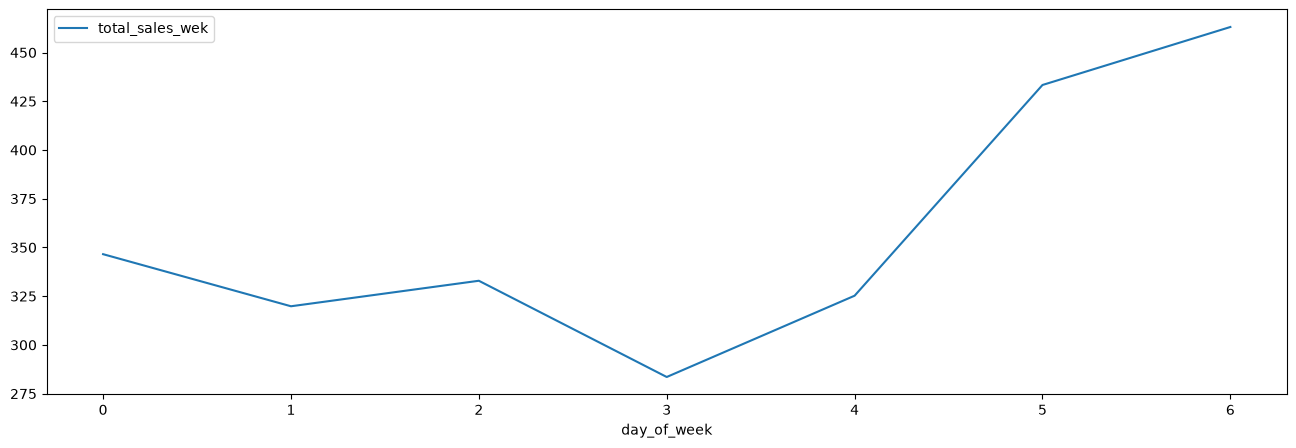

In [27]:
week_sales.plot(figsize=(16, 5))

## 3. Time Series Decomposition
Decompose daily sales into trend, seasonality, and residuals using statsmodels.

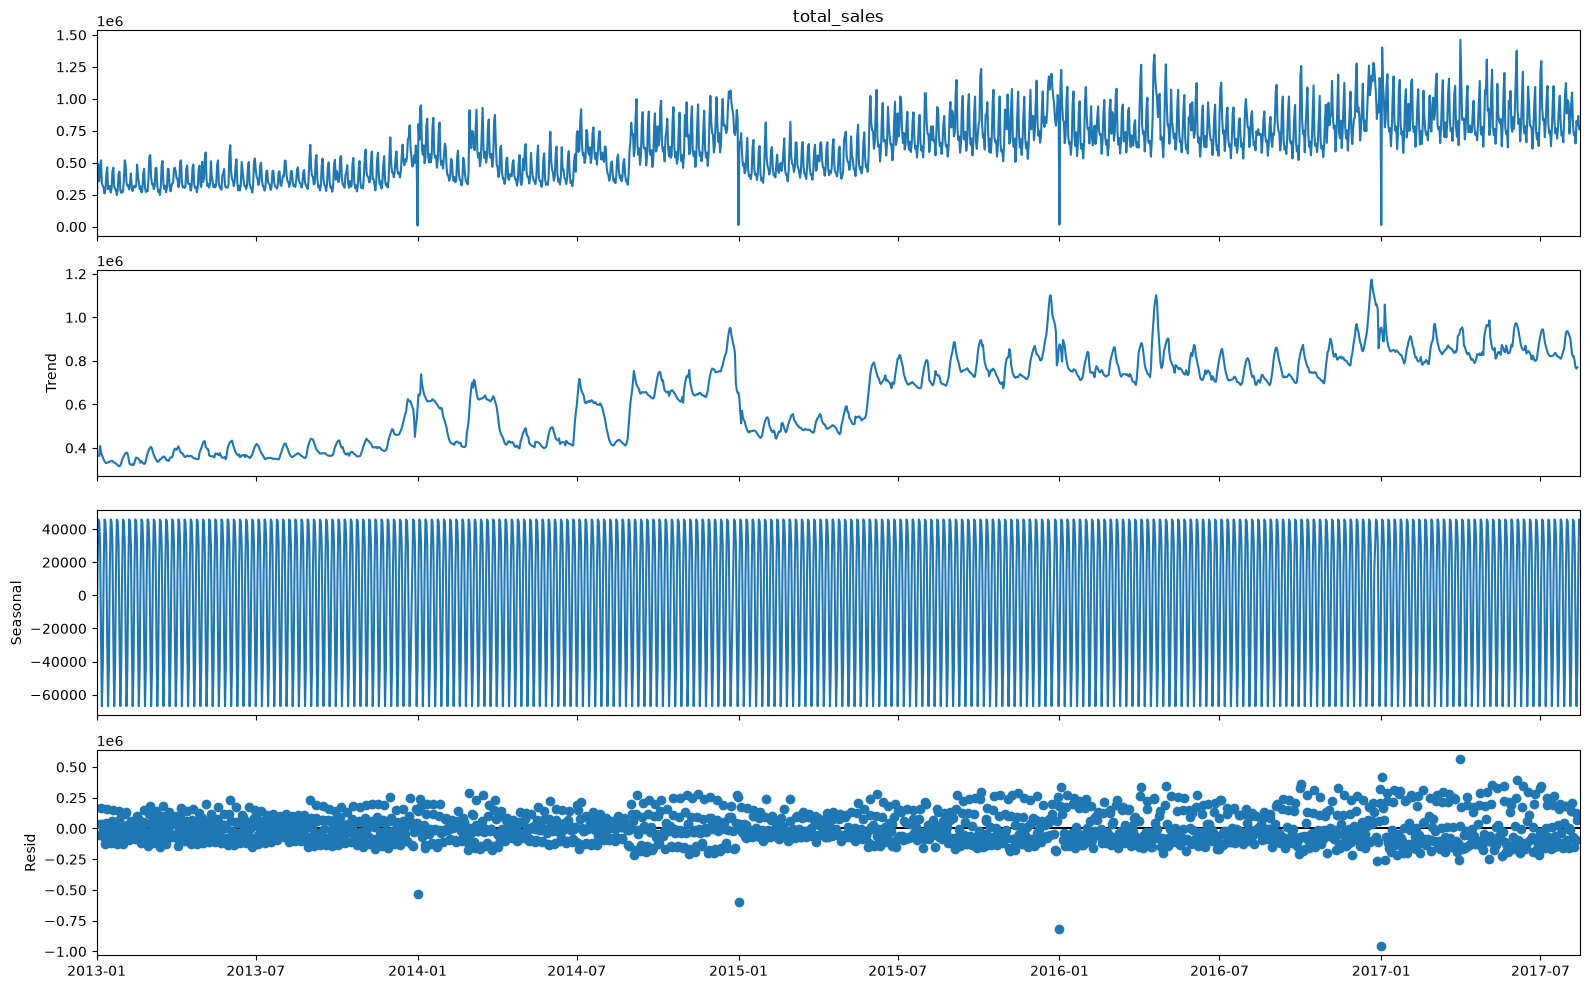

In [35]:
result = seasonal_decompose(daily_sales['total_sales'], period=7)
result.plot()
plt.gcf().set_size_inches(16, 10)
plt.tight_layout()
plt.show()

## Conclusion
There is an upward trend. There is a clear seasonality. Mondays, tuesdays, wednesdays, fridays have +- same amount of sales, while dropping on thursdays and increased sales on weekends. There are anomalies in the beginning of each year which leads to an insight of stores having New Year holidays with zero sales.